# Setup
Project paths and constants.

In [66]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import mobilenet_v2
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [68]:
PROJECT_ROOT = r"C:\Users\banya\crop-disease-detection-deep-learning"

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "new_plant_diseases_dataset")
VALID_DIR = os.path.join(DATA_DIR, "valid")

MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")

MOBILENET_PATH = os.path.join(MODELS_DIR, "crop_disease_mobilenetv2_1.keras")
EFFICIENTNET_PATH = os.path.join(MODELS_DIR, "crop_disease_efficientnetb0_2.keras")

COMPARISON_JSON_PATH = os.path.join(RESULTS_DIR, "model_comparison.json")
COMPARISON_TABLE_PATH = os.path.join(RESULTS_DIR, "model_comparison_table.csv")

COMPARISON_ACCURACY_FIG_PATH = os.path.join(FIGURES_DIR, "model_comparison_accuracy.png")
COMPARISON_LOSS_FIG_PATH = os.path.join(FIGURES_DIR, "model_comparison_loss.png")

BEST_REPORT_PATH = os.path.join(RESULTS_DIR, "efficientnetb0_classification_report.csv")
BEST_METRICS_PATH = os.path.join(RESULTS_DIR, "best_model_metrics.json")

BEST_CONFUSION_MATRIX_PATH = os.path.join(FIGURES_DIR, "efficientnetb0_confusion_matrix.png")
BEST_SAMPLE_PREDICTIONS_PATH = os.path.join(FIGURES_DIR, "efficientnetb0_sample_predictions.png")
BEST_GRADCAM_PATH = os.path.join(FIGURES_DIR, "efficientnetb0_gradcam_examples.png")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 30


# Load Dataset
Use `valid/` for comparison and final evaluation.

In [69]:
def prepare_dataset(model_name):
    if model_name == "MobileNetV2":
        return raw_valid_ds.map(
            lambda images, labels: (
                mobilenet_v2.preprocess_input(tf.cast(images, tf.float32)),
                labels
            )
        ).prefetch(tf.data.AUTOTUNE)

    return raw_valid_ds.prefetch(tf.data.AUTOTUNE)

# Load Models
Load the two trained `.keras` files.

In [70]:
mobilenet_model = keras.models.load_model(MOBILENET_PATH)
efficientnet_model = keras.models.load_model(EFFICIENTNET_PATH)

print("Loaded MobileNetV2:", MOBILENET_PATH)
print("Loaded EfficientNetB0:", EFFICIENTNET_PATH)

Loaded MobileNetV2: C:\Users\banya\crop-disease-detection-deep-learning\models\crop_disease_mobilenetv2_1.keras
Loaded EfficientNetB0: C:\Users\banya\crop-disease-detection-deep-learning\models\crop_disease_efficientnetb0_2.keras


# Compare Models
Evaluate both models on `valid/`.

In [71]:
comparison_rows = []

for model_name, model_path, model in [
    ("MobileNetV2", MOBILENET_PATH, mobilenet_model),
    ("EfficientNetB0", EFFICIENTNET_PATH, efficientnet_model),
]:
    print("\nEvaluating:", model_name)
    print("Model path:", model_path)

    eval_ds = prepare_dataset(model_name)
    val_loss, val_accuracy = model.evaluate(eval_ds, verbose=1)

    comparison_rows.append({
        "model": model_name,
        "model_path": model_path,
        "validation_accuracy": float(val_accuracy),
        "validation_loss": float(val_loss),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["validation_accuracy", "validation_loss"],
    ascending=[False, True],
).reset_index(drop=True)

comparison_df


Evaluating: MobileNetV2
Model path: C:\Users\banya\crop-disease-detection-deep-learning\models\crop_disease_mobilenetv2_1.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 91s 162ms/step - accuracy: 0.9597 - loss: 0.1234

Evaluating: EfficientNetB0
Model path: C:\Users\banya\crop-disease-detection-deep-learning\models\crop_disease_efficientnetb0_2.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 137s 245ms/step - accuracy: 0.9702 - loss: 0.0925


,model,model_path,validation_accuracy,validation_loss
0,EfficientNetB0,C:\Users\banya\crop-disease-detection-deep-lea...,0.970237,0.092496
1,MobileNetV2,C:\Users\banya\crop-disease-detection-deep-lea...,0.959652,0.123442


In [72]:
comparison_results = {
    row["model"]: {
        "validation_accuracy": row["validation_accuracy"],
        "validation_loss": row["validation_loss"],
        "model_path": row["model_path"],
        "evaluation_split": "valid folder"
    }
    for row in comparison_rows
}

best_row = comparison_df.iloc[0]

comparison_results["best_model"] = {
    "model": best_row["model"],
    "validation_accuracy": float(best_row["validation_accuracy"]),
    "validation_loss": float(best_row["validation_loss"]),
    "model_path": best_row["model_path"]
}

comparison_results["note"] = (
    "Both models were evaluated on the same labeled validation split. "
    "MobileNetV2 uses its standard preprocess_input function. "
    "EfficientNetB0 uses the raw image pipeline from the dataset loader."
)

with open(COMPARISON_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(comparison_results, f, indent=4)

comparison_df.to_csv(COMPARISON_TABLE_PATH, index=False)

print("Saved:", COMPARISON_JSON_PATH)
print("Saved:", COMPARISON_TABLE_PATH)

comparison_results

Saved: C:\Users\banya\crop-disease-detection-deep-learning\results\model_comparison.json
Saved: C:\Users\banya\crop-disease-detection-deep-learning\results\model_comparison_table.csv


{'MobileNetV2': {'validation_accuracy': 0.9596517086029053,
  'validation_loss': 0.12344176322221756,
  'model_path': 'C:\\Users\\banya\\crop-disease-detection-deep-learning\\models\\crop_disease_mobilenetv2_1.keras',
  'evaluation_split': 'valid folder'},
 'EfficientNetB0': {'validation_accuracy': 0.9702367186546326,
  'validation_loss': 0.09249648451805115,
  'model_path': 'C:\\Users\\banya\\crop-disease-detection-deep-learning\\models\\crop_disease_efficientnetb0_2.keras',
  'evaluation_split': 'valid folder'},
 'best_model': {'model': 'EfficientNetB0',
  'validation_accuracy': 0.9702367186546326,
  'validation_loss': 0.09249648451805115,
  'model_path': 'C:\\Users\\banya\\crop-disease-detection-deep-learning\\models\\crop_disease_efficientnetb0_2.keras'},
 'note': 'Both models were evaluated on the same labeled validation split. MobileNetV2 uses its standard preprocess_input function. EfficientNetB0 uses the raw image pipeline from the dataset loader.'}

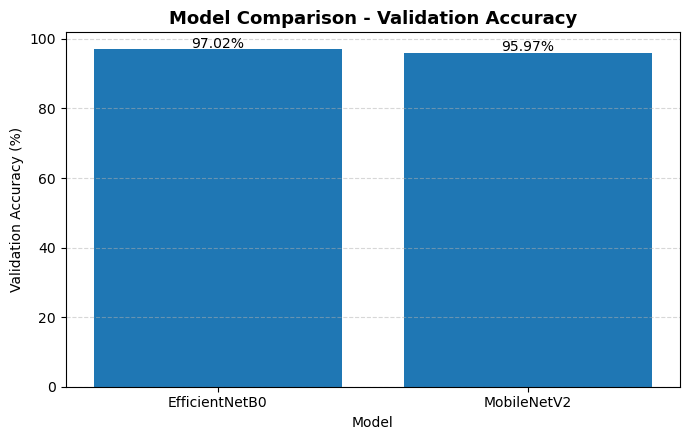

In [73]:
plt.figure(figsize=(7, 4.5))
plt.bar(comparison_df["model"], comparison_df["validation_accuracy"] * 100)
plt.title("Model Comparison - Validation Accuracy", fontsize=13, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy (%)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, value in enumerate(comparison_df["validation_accuracy"] * 100):
    plt.text(i, value + 0.4, f"{value:.2f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(COMPARISON_ACCURACY_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

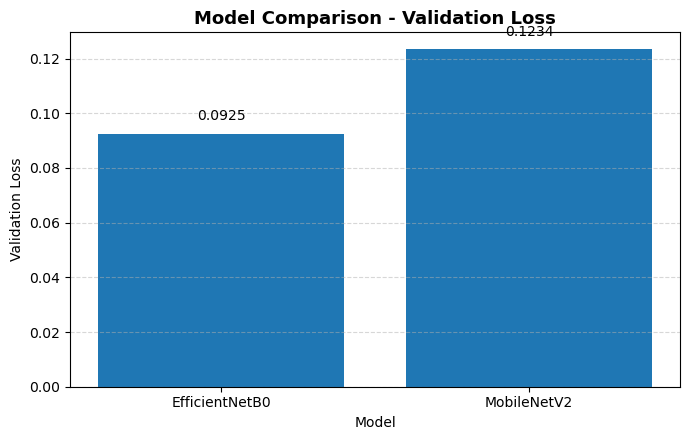

In [74]:
plt.figure(figsize=(7, 4.5))
plt.bar(comparison_df["model"], comparison_df["validation_loss"])
plt.title("Model Comparison - Validation Loss", fontsize=13, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Validation Loss")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, value in enumerate(comparison_df["validation_loss"]):
    plt.text(i, value + 0.005, f"{value:.4f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(COMPARISON_LOSS_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

# Best Model
Use the model with higher validation accuracy.

In [75]:
best_model_name = comparison_df.iloc[0]["model"]
best_model_path = comparison_df.iloc[0]["model_path"]

if best_model_name == "MobileNetV2":
    best_model = mobilenet_model
else:
    best_model = efficientnet_model

print("Best model:", best_model_name)
print("Best model path:", best_model_path)

Best model: EfficientNetB0
Best model path: C:\Users\banya\crop-disease-detection-deep-learning\models\crop_disease_efficientnetb0_2.keras


In [76]:
best_eval_ds = prepare_dataset(best_model_name)

y_true = []
y_pred = []

for images, labels in best_eval_ds:
    predictions = best_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Validation samples:", len(y_true))

Validation samples: 17572


# Classification Report
Predict on `valid/` and save the report for the best model.

In [77]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(BEST_REPORT_PATH)

print("Saved:", BEST_REPORT_PATH)
report_df.head()

Saved: C:\Users\banya\crop-disease-detection-deep-learning\results\efficientnetb0_classification_report.csv


,precision,recall,f1-score,support
Apple___Apple_scab,0.985325,0.932540,0.958206,504.0
Apple___Black_rot,0.993976,0.995976,0.994975,497.0
Apple___Cedar_apple_rust,0.997664,0.970455,0.983871,440.0
Apple___healthy,0.941620,0.996016,0.968054,502.0
Blueberry___healthy,1.000000,1.000000,1.000000,454.0


# Confusion Matrix
Save the validation confusion matrix for the best model.

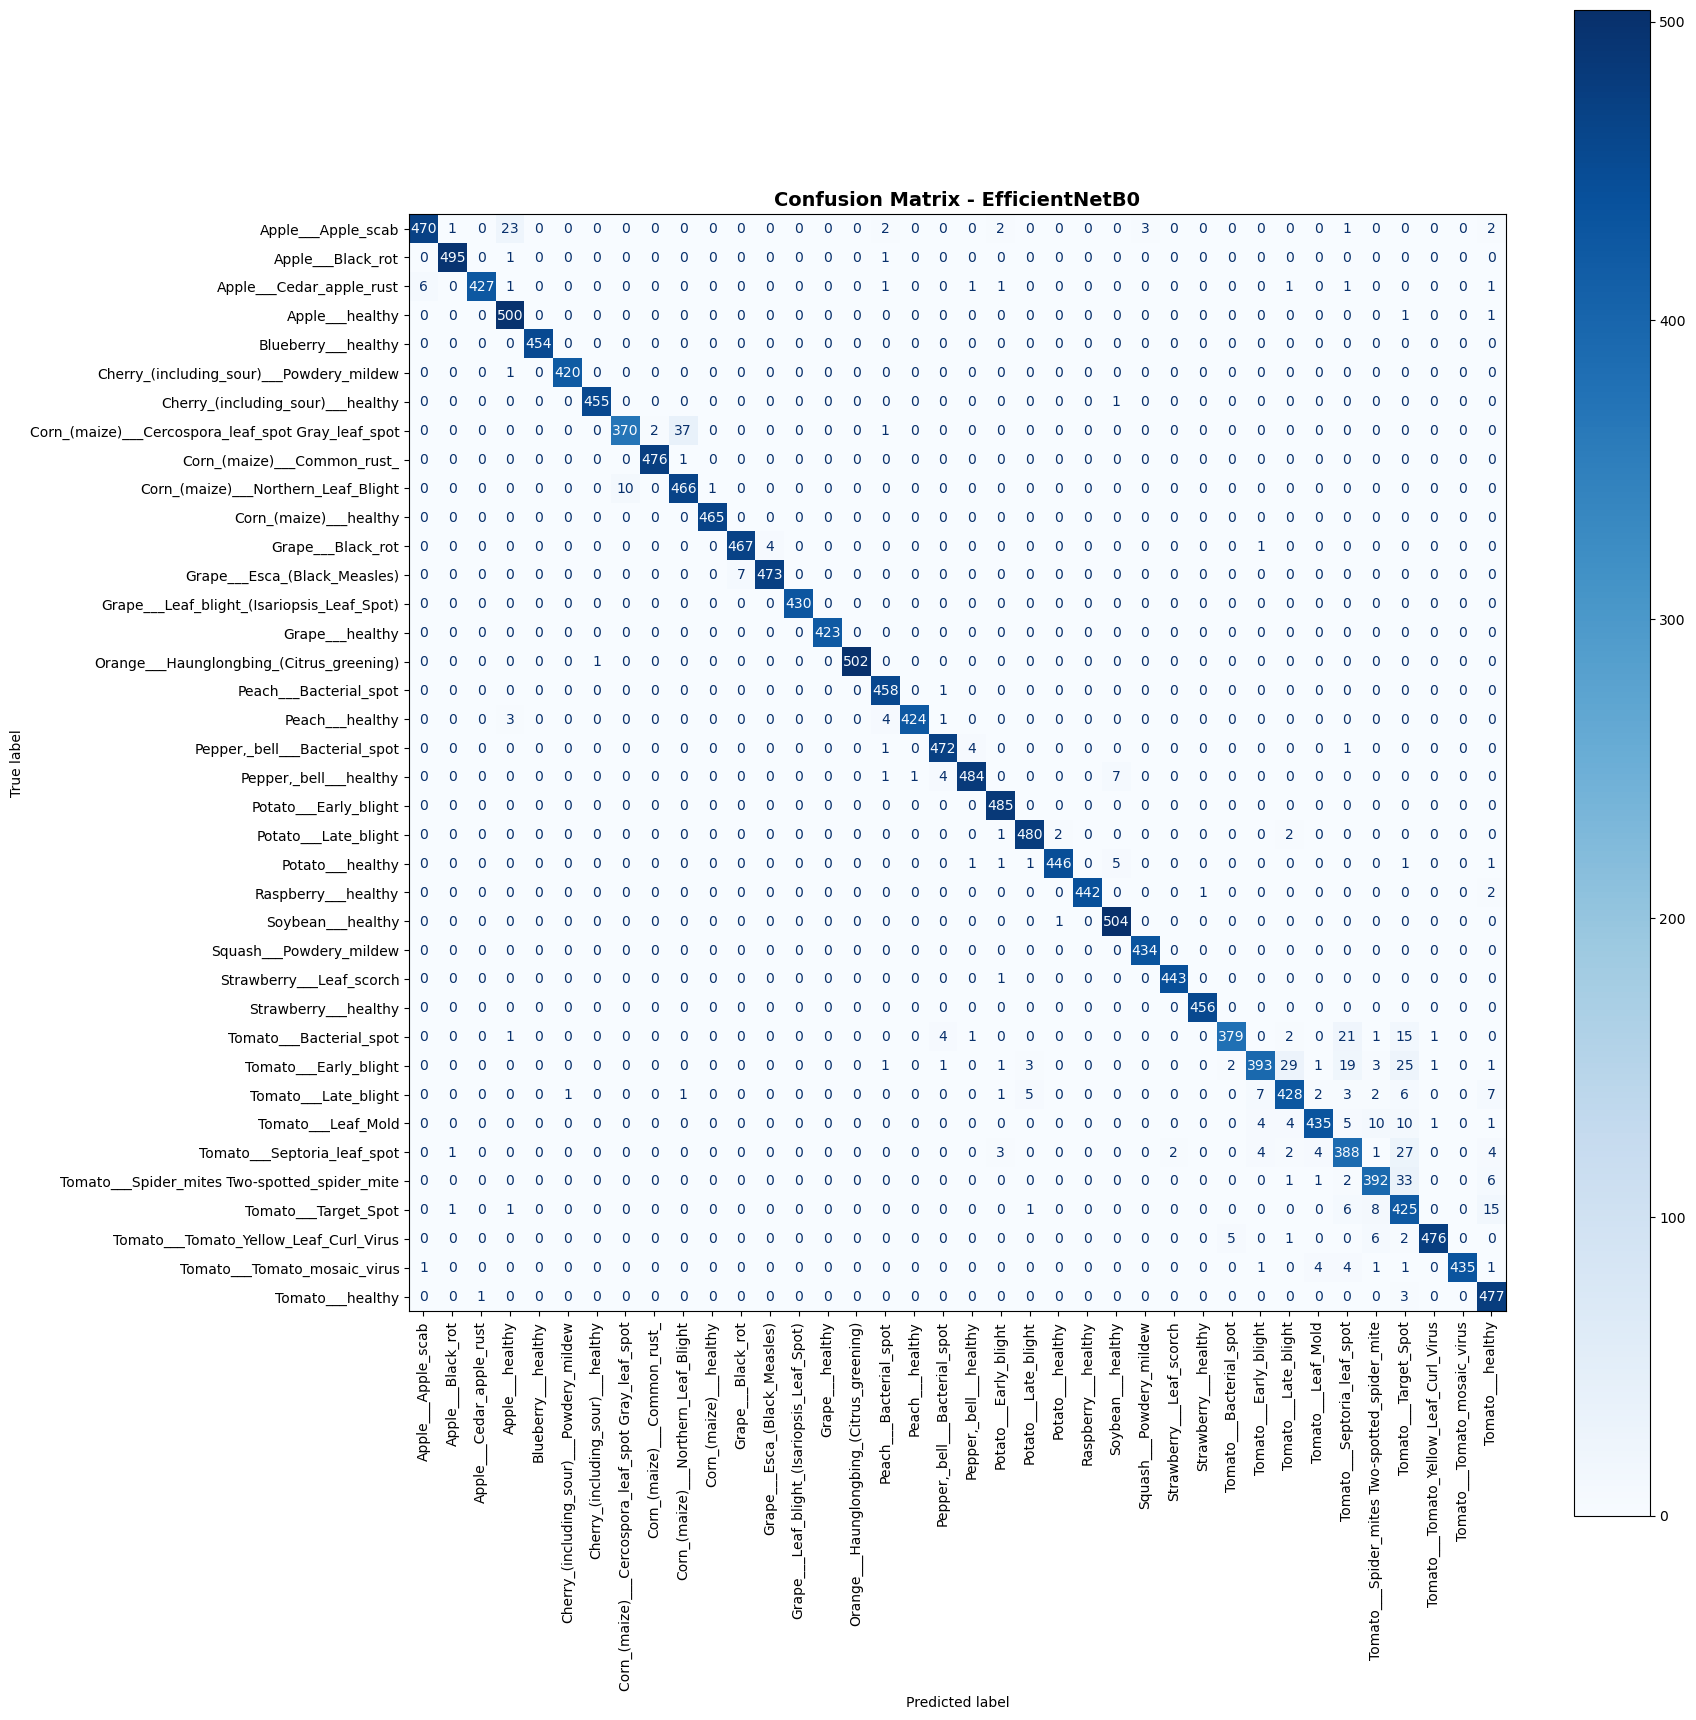

Saved: C:\Users\banya\crop-disease-detection-deep-learning\results\figures\efficientnetb0_confusion_matrix.png


In [78]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(18, 18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True,
    values_format="d"
)

plt.title(f"Confusion Matrix - {best_model_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(BEST_CONFUSION_MATRIX_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", BEST_CONFUSION_MATRIX_PATH)

# Sample Predictions
Show 16 validation images with labels and confidence.

In [79]:
def clean_label(label):
    if "___" in label:
        crop, condition = label.split("___", maxsplit=1)
    else:
        crop, condition = label, "Unknown"

    crop = crop.replace("_", " ").strip()
    condition = condition.replace("_", " ").strip()

    return crop, condition

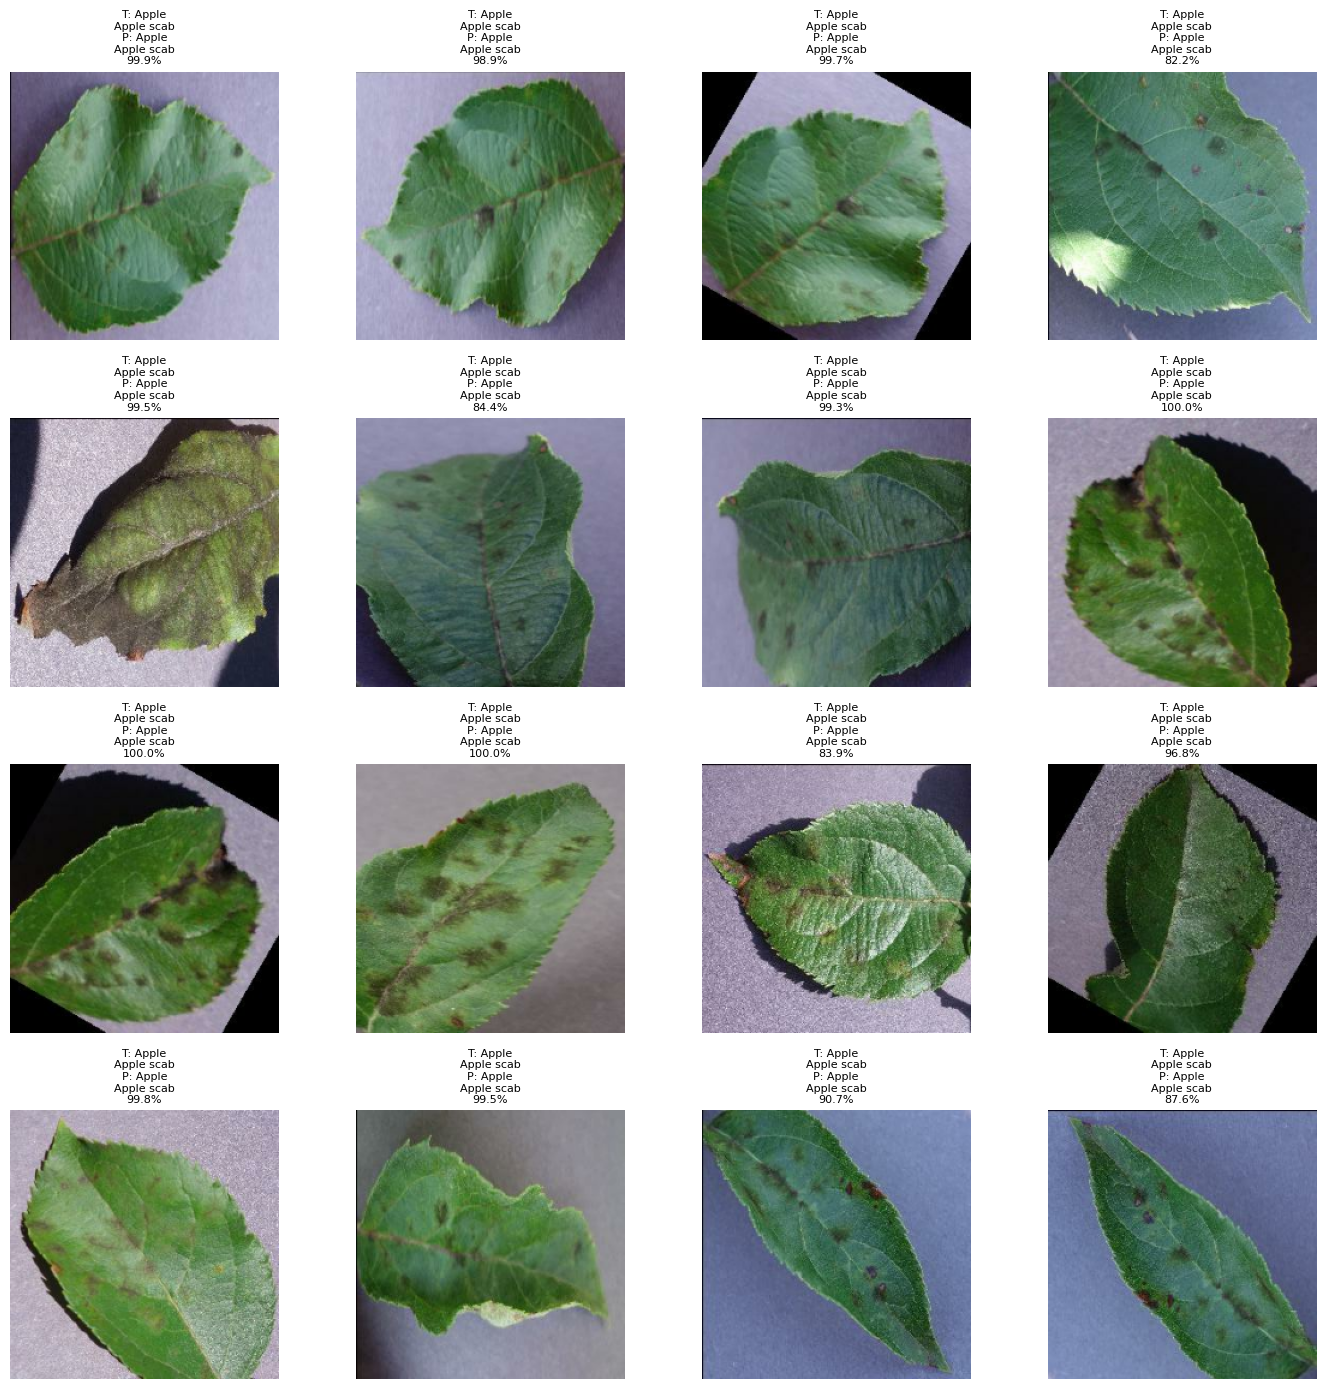

Saved: C:\Users\banya\crop-disease-detection-deep-learning\results\figures\efficientnetb0_sample_predictions.png


In [80]:
plt.figure(figsize=(14, 14))

for images, labels in raw_valid_ds.take(1):
    if best_model_name == "MobileNetV2":
        model_inputs = mobilenet_v2.preprocess_input(tf.cast(images, tf.float32))
    else:
        model_inputs = images

    predictions = best_model.predict(model_inputs, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    confidence_scores = np.max(predictions, axis=1)

    for i in range(min(16, len(images))):
        img = images[i].numpy().astype("uint8")

        true_label = class_names[int(labels[i].numpy())]
        predicted_label = class_names[int(predicted_classes[i])]
        confidence = confidence_scores[i] * 100

        true_crop, true_condition = clean_label(true_label)
        pred_crop, pred_condition = clean_label(predicted_label)

        plt.subplot(4, 4, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"T: {true_crop}\n{true_condition}\n"
            f"P: {pred_crop}\n{pred_condition}\n"
            f"{confidence:.1f}%",
            fontsize=8
        )

plt.tight_layout()
plt.savefig(BEST_SAMPLE_PREDICTIONS_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", BEST_SAMPLE_PREDICTIONS_PATH)

In [81]:
best_metrics = {
    "best_model": best_model_name,
    "model_path": best_model_path,
    "validation_accuracy": float(comparison_df.iloc[0]["validation_accuracy"]),
    "validation_loss": float(comparison_df.iloc[0]["validation_loss"]),
    "num_classes": int(num_classes),
    "evaluation_split": "valid folder"
}

with open(BEST_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(best_metrics, f, indent=4)

print("Saved:", BEST_METRICS_PATH)
best_metrics

Saved: C:\Users\banya\crop-disease-detection-deep-learning\results\best_model_metrics.json


{'best_model': 'EfficientNetB0',
 'model_path': 'C:\\Users\\banya\\crop-disease-detection-deep-learning\\models\\crop_disease_efficientnetb0_2.keras',
 'validation_accuracy': 0.9702367186546326,
 'validation_loss': 0.09249648451805115,
 'num_classes': 38,
 'evaluation_split': 'valid folder'}

# Grad-CAM
Grad-CAM highlights image regions that influenced the prediction.

In [83]:
gradcam_model = keras.models.clone_model(best_model)
gradcam_model.set_weights(best_model.get_weights())

sample_batch = next(iter(raw_valid_ds))
sample_image = np.expand_dims(sample_batch[0][0].numpy(), axis=0)

if best_model_name == "MobileNetV2":
    sample_image_for_model = mobilenet_v2.preprocess_input(tf.cast(sample_image, tf.float32))
else:
    sample_image_for_model = sample_image

_ = gradcam_model(sample_image_for_model, training=False)

base_model_index, base_model = get_base_model(gradcam_model)
last_conv_layer_name = get_last_conv_layer_name(base_model)

print("Grad-CAM model:", best_model_name)
print("Base model:", base_model.name)
print("Last conv layer:", last_conv_layer_name)

Grad-CAM model: EfficientNetB0
Base model: efficientnetb0
Last conv layer: top_conv


In [ ]:
gradcam_images = []
gradcam_titles = []

for images, labels in raw_valid_ds.take(1):
    gradcam_batch = images[:4]
    gradcam_labels = labels[:4].numpy()

    for i in range(gradcam_batch.shape[0]):
        raw_image = gradcam_batch[i].numpy().astype("uint8")
        model_input = np.expand_dims(raw_image, axis=0)

        if best_model_name == "MobileNetV2":
            model_input_for_model = mobilenet_v2.preprocess_input(tf.cast(model_input, tf.float32))
        else:
            model_input_for_model = model_input

        pred_probs = best_model.predict(model_input_for_model, verbose=0)
        pred_id = int(np.argmax(pred_probs[0]))
        confidence = float(np.max(pred_probs[0]) * 100)

        heatmap = make_gradcam_heatmap(
            model_input_for_model,
            gradcam_model,
            base_model_index,
            base_model,
            last_conv_layer_name
        )

        overlay = overlay_gradcam(raw_image, heatmap) # pyright: ignore[reportUndefinedVariable]

        true_label = class_names[int(gradcam_labels[i])]
        pred_label = class_names[pred_id]

        gradcam_images.append(overlay)
        gradcam_titles.append(
            f"T: {true_label}\nP: {pred_label}\nConf: {confidence:.1f}%"
        )

    break

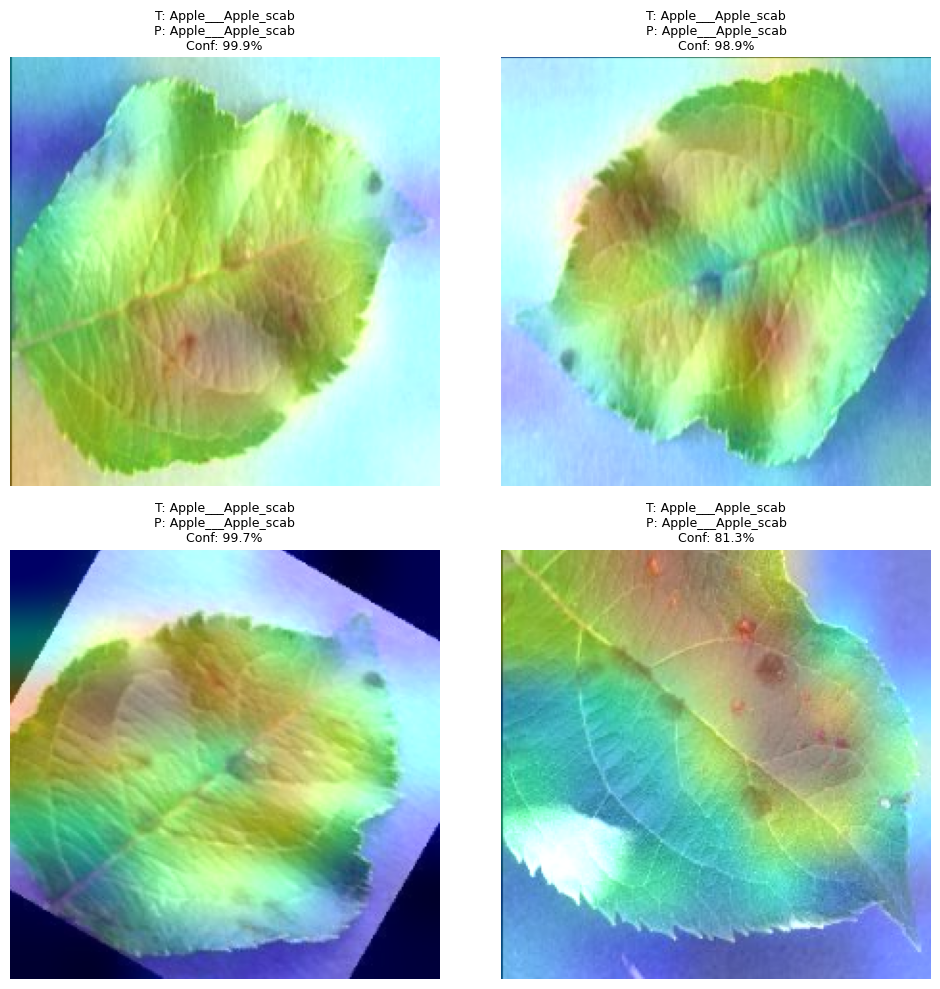

Saved: C:\Users\banya\crop-disease-detection-deep-learning\results\figures\efficientnetb0_gradcam_examples.png


In [85]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(gradcam_images[i])
    ax.set_title(gradcam_titles[i], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(BEST_GRADCAM_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", BEST_GRADCAM_PATH)

# Short Summary
Comparison uses `crop_disease_efficientnetb0_2.keras` and `crop_disease_mobilenetv2.keras`.

The best model is chosen from actual validation results in this notebook.

In [87]:
print("Model comparison complete.")
print("Best model:", best_model_name)
print("Validation accuracy:", comparison_df.iloc[0]["validation_accuracy"])
print("Validation loss:", comparison_df.iloc[0]["validation_loss"])
print("Saved comparison:", COMPARISON_JSON_PATH)
print("Saved report:", BEST_REPORT_PATH)
print("Saved confusion matrix:", BEST_CONFUSION_MATRIX_PATH)
print("Saved sample predictions:", BEST_SAMPLE_PREDICTIONS_PATH)
print("Saved Grad-CAM:", BEST_GRADCAM_PATH)

Model comparison complete.
Best model: EfficientNetB0
Validation accuracy: 0.9702367186546326
Validation loss: 0.09249648451805115
Saved comparison: C:\Users\banya\crop-disease-detection-deep-learning\results\model_comparison.json
Saved report: C:\Users\banya\crop-disease-detection-deep-learning\results\efficientnetb0_classification_report.csv
Saved confusion matrix: C:\Users\banya\crop-disease-detection-deep-learning\results\figures\efficientnetb0_confusion_matrix.png
Saved sample predictions: C:\Users\banya\crop-disease-detection-deep-learning\results\figures\efficientnetb0_sample_predictions.png
Saved Grad-CAM: C:\Users\banya\crop-disease-detection-deep-learning\results\figures\efficientnetb0_gradcam_examples.png
